In [3]:
import pandas as pd

pd.set_option("display.max_rows",30)

human_Percentages_df=pd.read_csv("../human_predictions/output_all_withPercentages.csv")
llm_Percentages_df=pd.read_csv("../llm_predictions/result_vwp50_scene_table.csv")

llm_Percentages_df=llm_Percentages_df.rename(columns={"Item":"stimuliId","Condition":"condition","Object":"obj"})
llm_Percentages_df["stimuliId"] = llm_Percentages_df["stimuliId"].astype(int)

#OBSOLET AFTER UPDATE
#remove strange star symbols that come up in strings (even though we like stars they dont help here, sry Fei //Jonathan ^^)
#llm_Percentages_df["obj"] = (
#    llm_Percentages_df["obj"]
#    .str.replace(r"^[^\w]+", "", regex=True)
#    .str.strip()
#)

#change naming on human percentages:
human_Percentages_df.rename(columns={'percentages': 'human_percent'}, inplace=True)

#fixing different denotations of condition:
llm_Percentages_df["condition"] = llm_Percentages_df["condition"].replace("Restrictive", "restrictive")
llm_Percentages_df["condition"] = llm_Percentages_df["condition"].replace("Non-restr.", "non-restrictive")
#r=llm_Percentages_df[llm_Percentages_df["obj"]=="cake"]
#r
human_Percentages_df

,stimuliId,condition,obj,count_per_obj_per_part,human_percent,countOfNonZeroParticipants
0,1,non-restrictive,ball,66,0.377143,7.0
1,1,non-restrictive,cake,93,0.531429,7.0
2,1,non-restrictive,toy-car,16,0.091429,7.0
3,1,non-restrictive,toy-train,0,0.000000,7.0
4,1,restrictive,ball,0,0.000000,2.0
...,...,...,...,...,...,...
395,50,non-restrictive,stamp,157,0.923529,3.0
396,50,restrictive,envelope,66,0.245353,7.0
397,50,restrictive,rubberband,12,0.044610,7.0
398,50,restrictive,scissors,66,0.245353,7.0


In [ ]:
#TODO: investigate human percentages for trials where all are zero
human_Percentages_df[human_Percentages_df["stimuliId"]==45]

#learning!--trials (ie combinations of stimuliid and condition) that have NaN as countOfNonZeroParticipants need to be excluded. 

,stimuliId,partID,condition,obj,count_per_obj_per_part,percentages,countOfNonZeroParticipants
164,45,1,non-restrictive,dough,81,0.532895,3.0
165,45,1,non-restrictive,glass,0,0.000000,3.0
166,45,1,non-restrictive,ladle,0,0.000000,3.0
167,45,1,non-restrictive,hammer,0,0.000000,3.0
236,45,2,restrictive,hammer,0,NaN,NaN
...,...,...,...,...,...,...,...
4175,45,21,non-restrictive,glass,0,0.000000,3.0
4244,45,22,restrictive,glass,0,NaN,NaN
4245,45,22,restrictive,ladle,0,NaN,NaN
4246,45,22,restrictive,hammer,0,NaN,NaN


In [ ]:
#check how many predictions we have on avg

In [ ]:
""" obsolet as we aleady did this iun the human pipeline for metric 1

#first before comparing we need to aggregate. not over all participants of a trial 
# but over all participants with the same contidion (4-restrictive 4 non restrictive) however some may not be present yet...
avg_df_human = (
    human_Percentages_df
    .groupby(["stimuliId", "condition", "obj"])
    .agg(
        avg_percent=("percent", "mean"),
        n_participants=("partID", "nunique")
    )
    .reset_index()
)

avg_df_human.to_csv("02_intermediate_human_aggregation.csv")

#another approach would be to exclude all those that have only zero percentages before aggregating. here we do it after to retain as many values as possible
avg_df_human["total_percent"] = (
    avg_df_human.groupby(["stimuliId", "condition"])["avg_percent"]
      .transform("sum")
)
avg_df_human_totalOne=avg_df_human[avg_df_human["total_percent"]==1.0] #only 44 !!!!! ???
avg_df_human_totalOne

"""

,stimuliId,condition,obj,avg_percent,n_participants,total_percent


In [4]:
human_Percentages_df.groupby(["stimuliId", "condition"])["countOfNonZeroParticipants"].sum()

stimuliId  condition      
1          non-restrictive    28.0
           restrictive         8.0
2          non-restrictive     4.0
           restrictive        28.0
3          non-restrictive    16.0
                              ... 
48         restrictive        24.0
49         non-restrictive    20.0
           restrictive         4.0
50         non-restrictive    12.0
           restrictive        28.0
Name: countOfNonZeroParticipants, Length: 100, dtype: float64

In [5]:
#check after avg over all participants how many stimuli got only 0 percentages...
#-->check predictionrate 
nan_count = (
    human_Percentages_df[
        human_Percentages_df["countOfNonZeroParticipants"].isna()
    ][["stimuliId", "condition"]]
    .drop_duplicates()
    .shape[0]
)
nan_count 
#__>8/100 codnitiontrials yield prediciton

8

In [6]:
#now we want to create a shared dataframe that maps the percentages contains both human and llm prediction per word per condition

#merge on ritgh because llm should be calculated for all

#maybe there still remains some kind of mismatch ? 400 rows (4*50*2 seems how it should be, why are there more )
#inner 378 --> this is most likely because we dont have values for all combinations yet //participant 6,7,8 are missing. 

#so for know we use inner

shared_df=human_Percentages_df.merge(llm_Percentages_df, on=["stimuliId","condition","obj"],how="left")

#not sure what titalk one is ??
#shared_totalOne_df=avg_df_human_totalOne.merge(llm_Percentages_df, on=["stimuliId","condition","obj"],how="inner")
#shared_totalOne_df
shared_df


,stimuliId,condition,obj,count_per_obj_per_part,human_percent,countOfNonZeroParticipants,Verb,Is_Target,Surprisal (bits),P_norm,Rank,ΔS (bits)
0,1,non-restrictive,ball,66,0.377143,7.0,move,False,4.953,0.9934,1.0,-6.202
1,1,non-restrictive,cake,93,0.531429,7.0,move,True,12.443,0.0055,2.0,6.482
2,1,non-restrictive,toy-car,16,0.091429,7.0,NaN,NaN,NaN,NaN,NaN,NaN
3,1,non-restrictive,toy-train,0,0.000000,7.0,NaN,NaN,NaN,NaN,NaN,NaN
4,1,restrictive,ball,0,0.000000,2.0,eat,False,11.156,0.0266,2.0,-6.202
...,...,...,...,...,...,...,...,...,...,...,...,...
395,50,non-restrictive,stamp,157,0.923529,3.0,pick up,True,15.759,0.0295,3.0,0.876
396,50,restrictive,envelope,66,0.245353,7.0,lick,False,12.571,0.7792,1.0,-0.571
397,50,restrictive,rubberband,12,0.044610,7.0,NaN,NaN,NaN,NaN,NaN,NaN
398,50,restrictive,scissors,66,0.245353,7.0,lick,False,16.736,0.0435,3.0,-5.245


Text(0.5, 1.0, 'LLM predictions vs. Human predictions')

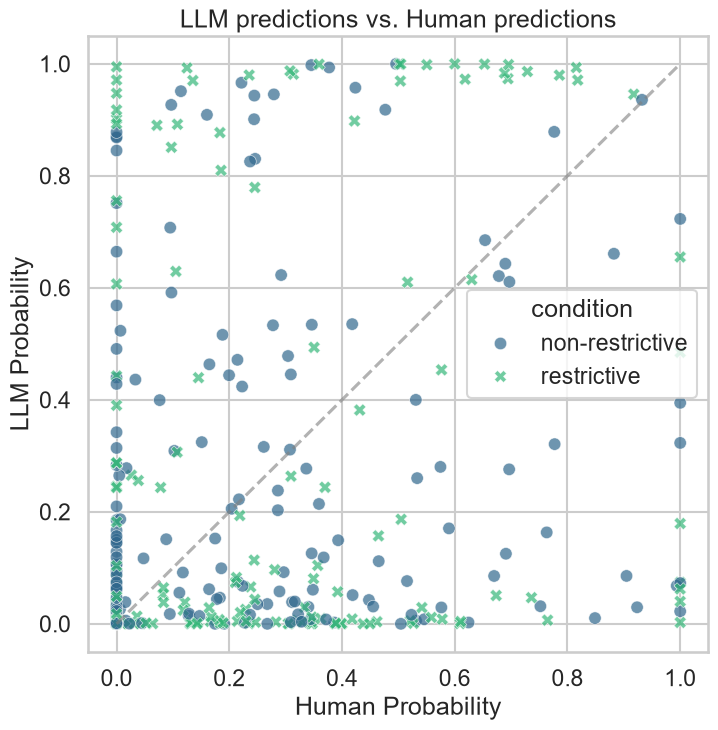

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")

fig, ax = plt.subplots(figsize=(8, 8))

sns.scatterplot(
    data=shared_df,
    x="human_percent",
    y="P_norm",
    hue="condition",       
    style="condition",     
    s=80,                 
    alpha=0.7,             
    edgecolor="white",
    linewidth=0.5,
    palette="viridis",
    ax=ax
)

# Diagonale (perfekte Übereinstimmung) einzeichnen
lims = [0, 1]  # anpassen, falls Werte nicht zwischen 0 und 1 liegen
ax.plot(lims, lims, ls="--", color="gray", alpha=0.6, label="perfect agreement")

ax.set_xlabel("Human Probability")
ax.set_ylabel("LLM Probability")
ax.set_title("LLM predictions vs. Human predictions")

ValueError: Could not interpret value `avg_percent` for `x`. An entry with this name does not appear in `data`.

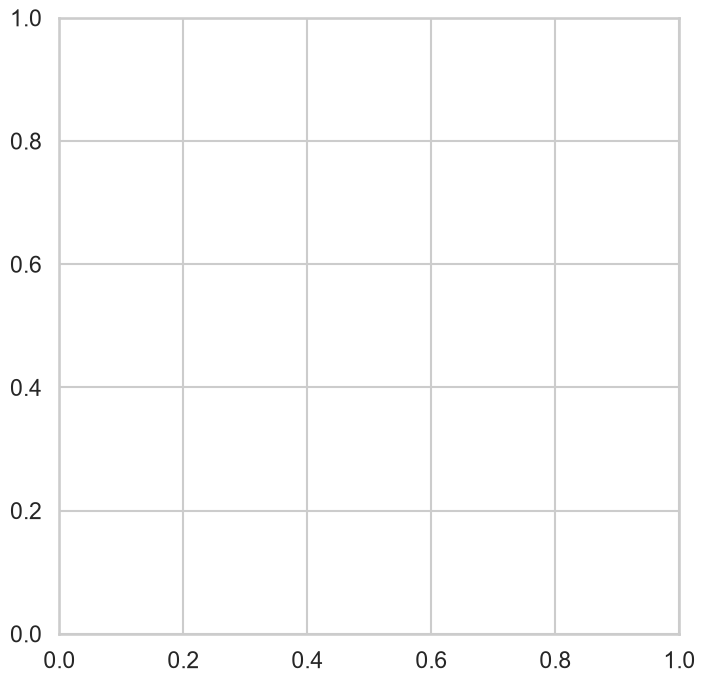

In [9]:
shared_df_targets=shared_df[shared_df["Is_Target"]==True]


fig, ax = plt.subplots(figsize=(8, 8))

sns.scatterplot(
    data=shared_df_targets,
    x="avg_percent",
    y="P_norm",
    hue="condition",       
    style="condition",     
    s=80,                 
    alpha=0.7,             
    edgecolor="white",
    linewidth=0.5,
    palette="viridis",
    ax=ax
)

# Diagonale (perfekte Übereinstimmung) einzeichnen
lims = [0, 1]  # anpassen, falls Werte nicht zwischen 0 und 1 liegen
ax.plot(lims, lims, ls="--", color="gray", alpha=0.6, label="perfect agreement")

ax.set_xlabel("Human Probability")
ax.set_ylabel("LLM Probability")
ax.set_title("LLM predictions vs. Human predictions")

Text(0.5, 1.0, 'LLM predictions vs. Human predictions')

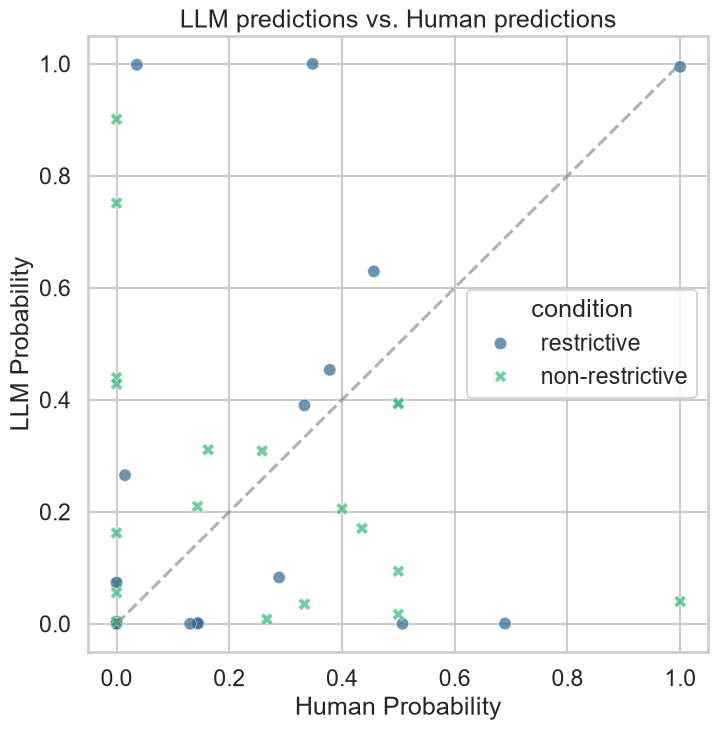

In [42]:
fig, ax = plt.subplots(figsize=(8, 8))

sns.scatterplot(
    data=shared_totalOne_df,
    x="avg_percent",
    y="P_norm",
    hue="condition",       
    style="condition",     
    s=80,                 
    alpha=0.7,             
    edgecolor="white",
    linewidth=0.5,
    palette="viridis",
    ax=ax
)

# Diagonale (perfekte Übereinstimmung) einzeichnen
lims = [0, 1]  # anpassen, falls Werte nicht zwischen 0 und 1 liegen
ax.plot(lims, lims, ls="--", color="gray", alpha=0.6, label="perfect agreement")

ax.set_xlabel("Human Probability")
ax.set_ylabel("LLM Probability")
ax.set_title("LLM predictions vs. Human predictions")

In [44]:
from scipy.spatial.distance import jensenshannon

jsd_df = (
    shared_totalOne_df
    .groupby(["stimuliId", "condition"])
    .apply(
        lambda g: jensenshannon(
            g.sort_values("obj")["avg_percent"],
            g.sort_values("obj")["P_norm"]
        ) ** 2
    )
    .reset_index(name="JSD")
)
jsd_df

,stimuliId,condition,JSD
0,2,restrictive,0.001875
1,5,restrictive,0.307866
2,11,restrictive,0.072091
3,17,non-restrictive,0.423025
4,28,non-restrictive,0.256682
5,35,restrictive,0.609261
6,36,non-restrictive,0.046065
7,38,non-restrictive,0.349608
8,42,restrictive,0.058558
9,49,non-restrictive,0.608701


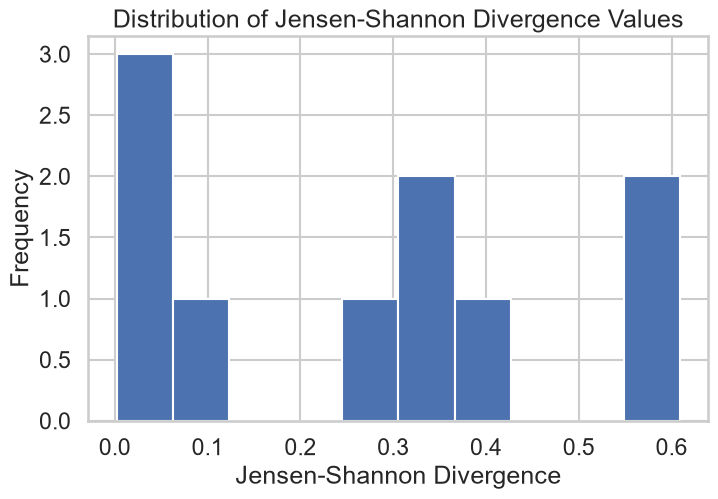

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(jsd_df["JSD"], bins=10)

plt.xlabel("Jensen-Shannon Divergence")
plt.ylabel("Frequency")
plt.title("Distribution of Jensen-Shannon Divergence Values")

plt.show()

In [60]:
sd_all_df = (
    shared_df
    .groupby(["stimuliId", "condition"])
    .apply(
        lambda g: jensenshannon(
            g.sort_values("obj")["avg_percent"],
            g.sort_values("obj")["P_norm"]
        ) ** 2
    )
    .reset_index(name="JSD")
)
#sd_all_df=sd_all_df[sd_all_df["condition"]=="non-restrictive"]

c:\Users\jonat\anaconda3\envs\etstudy\Lib\site-packages\scipy\spatial\distance.py:1280: RuntimeWarning: invalid value encountered in divide
  p = p / np.sum(p, axis=axis, keepdims=True)


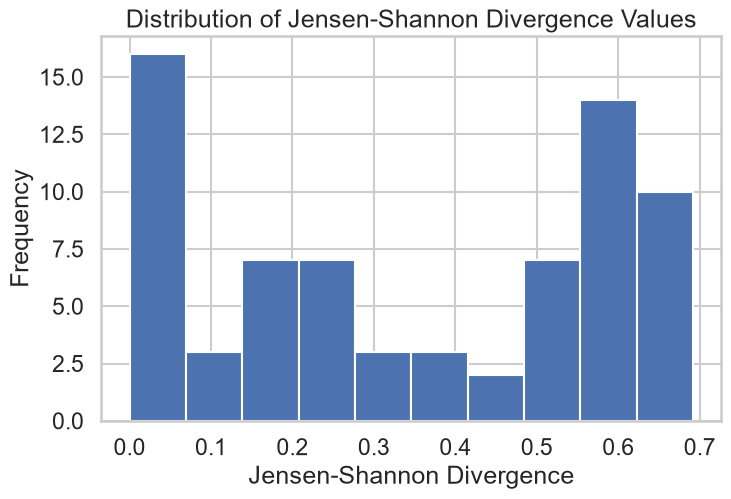

In [61]:
plt.figure(figsize=(8, 5))

plt.hist(sd_all_df["JSD"], bins=10)

plt.xlabel("Jensen-Shannon Divergence")
plt.ylabel("Frequency")
plt.title("Distribution of Jensen-Shannon Divergence Values")

plt.show()